In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bbg_utils.bdh_mm import bdh_mm
from bbg_utils.bdp_mm import bdp_mm
cds_mappings = pd.read_csv(r"S:\Structured Credit\Matt Stuff\cds_mappings\cds_mappings_final.csv", encoding="cp1252")
cds_mappings.head(5)

,CDS_Curve_ID,CDS_Ticker,Markit_CDS_Ticker,Markit_Currency,Markit_Doc_Clause,Markit_Seniority,Markit_Coupon_Lookup,BBG_Coupon_Dupe,Coupon_Mismatch,Coupon_Override,...,BBG_Equity_Ticker,Eq_Ticker_Company_Name,Company_Private,Ultimate_Parent_Equity_Ticker,Ultimate_Parent_Private,CDS_Public_Equity_Entity_Ticker,Best_Bond_Proxy_ISIN,Best_Bond_Proxy_Note,Markit_Ticker_Lookup_BBG_RedCode,Markit_Ticker_Mismatch
0,1,AAL,AMERAIAI,USD,XR14,SNRFOR,500.0,500.0,NaN,NaN,...,AAL US Equity,AMERICAN AIRLINES GROUP INC,N,AAL US Equity,N,AAL US Equity,US023771T329,NaN,AMERAIAI,NaN
1,2,ADT,THADT,USD,XR14,SNRFOR,500.0,500.0,NaN,NaN,...,1566019D US Equity,ADT SECURITY CORP/THE,Y,ADT US Equity,N,ADT US Equity,USU0073MAA81,NaN,THADT,NaN
2,3,ALIANT,ALLIHOAH,USD,XR14,SNRFOR,100.0,500.0,1.0,500.0,...,1426133D US Equity,ALLIANT HOLDINGS INTERMEDIAT,Y,1339681D US Equity,Y,NaN,USU0188CAH70,NaN,ALLIHOAH,NaN
3,4,AMKR,AMKR,USD,XR14,SNRFOR,500.0,500.0,NaN,NaN,...,AMKR US Equity,AMKOR TECHNOLOGY INC,N,AMKR US Equity,N,AMKR US Equity,NaN,NaN,AMKR,NaN
4,5,ARMK,ARAMSER,USD,XR14,SNRFOR,500.0,500.0,NaN,NaN,...,2387Z US Equity,ARAMARK SERVICES INC,Y,ARMK US Equity,N,ARMK US Equity,USU0389LAE12,NaN,ARAMSER,NaN


In [72]:
from databricks_utils import get_delta_table_mm

CACHE_DIR = r"S:\Structured Credit\Matt Stuff\claude_repos\cds_bond_basis\cache"

CDS_TRANSFORM_COLUMNS = [
    "published_date",
    "market_cds_ticker",
    "tenor",
    "cds_maturity",
    "cds_index",
    "tier",
    "currency",
    "doc_clause",
    "running_coupon",
    "par_spread",
    "conv_spread",
    "upfront",
    "cds_assumed_recovery",
    "all_upfront",
]

cds_transform_interpolated = get_delta_table_mm(
    "teams.structured_credit_abhutra.cds_transform_interpolated",
    cache_dir=CACHE_DIR,
    columns=CDS_TRANSFORM_COLUMNS,
    where="published_date >= '2025-01-01'",
    filename="cds_transform_interpolated_subset_2025.parquet",
)

[cache] cds_transform_interpolated_subset_2025.parquet is current — loading from disk


In [73]:
print(cds_transform_interpolated.shape)
cds_transform_interpolated.head(5)

(3605834, 14)


,published_date,market_cds_ticker,tenor,cds_maturity,cds_index,tier,currency,doc_clause,running_coupon,par_spread,conv_spread,upfront,cds_assumed_recovery,all_upfront
0,2026-07-06,ARGID,6M,2026-12-20,XO,SNRFOR,EUR,MM14,500.0,713.4439,713.8000,0.9574,0.4,3.2074
1,2026-07-06,ARGID,1Y,2027-06-20,XO,SNRFOR,EUR,MM14,500.0,916.3042,921.2093,3.7437,0.4,8.2437
2,2026-07-06,ARGID,1Y6M,2027-12-20,XO,SNRFOR,EUR,MM14,500.0,883.6929,887.3557,4.9880,0.4,11.4880
3,2026-07-06,ARGID,2Y,2028-06-20,XO,SNRFOR,EUR,MM14,500.0,851.0815,853.5021,5.9683,0.4,14.4683
4,2026-07-06,ARGID,2Y6M,2028-12-20,XO,SNRFOR,EUR,MM14,500.0,860.9743,864.9847,7.3639,0.4,17.5639


In [74]:
CDS_INDEX_FILTER = "IG"

cds_mappings_filtered = (
    cds_mappings[cds_mappings["CDS_Index"] == CDS_INDEX_FILTER][["CDS_Ticker", "Best_Bond_Proxy_ISIN"]]
    .rename(columns={"CDS_Ticker": "ticker", "Best_Bond_Proxy_ISIN": "BOND_ISIN"})
    .reset_index(drop=True)
)
print(cds_mappings_filtered.shape)
cds_mappings_filtered.head(5)

(141, 2)


,ticker,BOND_ISIN
0,RCL,USV7780TAQ68
1,ABX,US067901AA64
2,AEP,US025537AN10
3,AES,US00130HCC79
4,AIG,US026874DR53


In [75]:
bonds = cds_mappings_filtered.copy()
bonds["security"] = bonds["BOND_ISIN"] + " Corp"

bond_history = bdh_mm(
    bonds["security"],
    ["LAST_PRICE", "BLOOMBERG_MID_G_SPREAD"],
    start_date="2025-01-01",
)
print(bond_history.shape)
bond_history.head(5)

(50172, 4)


,security,date,LAST_PRICE,BLOOMBERG_MID_G_SPREAD
0,US00130HCC79 Corp,2026-07-07,95.594,92.279
1,US00206RGQ92 Corp,2026-07-07,98.424,53.949
2,US00287YDT38 Corp,2026-07-07,101.115,39.996
3,US007903BF39 Corp,2026-07-07,96.187,32.341
4,US012873AH83 Corp,2026-07-07,111.216,85.028


In [76]:
bond_maturity = bdp_mm(bonds["security"], ["MATURITY", "SECURITY_NAME"])
bond_maturity["MATURITY"] = pd.to_datetime(bond_maturity["MATURITY"])
bond_maturity.head(5)

,security,MATURITY,SECURITY_NAME
0,US00130HCC79 Corp,2030-07-15,AES 3.95 07/15/30
1,US00206RGQ92 Corp,2030-02-15,T 4.3 02/15/30
2,US00287YDT38 Corp,2031-03-15,ABBV 4.95 03/15/31
3,US007903BF39 Corp,2032-06-01,AMD 3.924 06/01/32
4,US012873AH83 Corp,2030-09-15,OVV 8 1/8 09/15/30


In [77]:
from datetime import date

def next_cds_maturity(maturity):
    """First standard semi-annual CDS maturity (20-Jun or 20-Dec) strictly after `maturity`."""
    maturity = pd.Timestamp(maturity).date()
    candidates = sorted(
        date(y, m, 20)
        for y in (maturity.year, maturity.year + 1)
        for m in (6, 12)
    )
    return next(c for c in candidates if c > maturity)

bond_maturity["target_cds_maturity"] = bond_maturity["MATURITY"].apply(next_cds_maturity)

bond_history = bond_history.merge(bond_maturity, on="security", how="left")
bond_history = bond_history.merge(bonds[["security", "ticker"]], on="security", how="left")

print(bond_history.shape)
bond_history.head(5)

(50172, 8)


,security,date,LAST_PRICE,BLOOMBERG_MID_G_SPREAD,MATURITY,SECURITY_NAME,target_cds_maturity,ticker
0,US00130HCC79 Corp,2026-07-07,95.594,92.279,2030-07-15,AES 3.95 07/15/30,2030-12-20,AES
1,US00206RGQ92 Corp,2026-07-07,98.424,53.949,2030-02-15,T 4.3 02/15/30,2030-06-20,SBC
2,US00287YDT38 Corp,2026-07-07,101.115,39.996,2031-03-15,ABBV 4.95 03/15/31,2031-06-20,ABBV
3,US007903BF39 Corp,2026-07-07,96.187,32.341,2032-06-01,AMD 3.924 06/01/32,2032-06-20,AMD
4,US012873AH83 Corp,2026-07-07,111.216,85.028,2030-09-15,OVV 8 1/8 09/15/30,2030-12-20,OVV


In [78]:
bond_history = bond_history.merge(
    cds_transform_interpolated[["market_cds_ticker", "published_date", "cds_maturity", "conv_spread"]],
    left_on=["ticker", "date", "target_cds_maturity"],
    right_on=["market_cds_ticker", "published_date", "cds_maturity"],
    how="left",
).drop(columns=["market_cds_ticker", "published_date", "cds_maturity"])

print(bond_history.shape)
bond_history.head(5)

(50172, 9)


,security,date,LAST_PRICE,BLOOMBERG_MID_G_SPREAD,MATURITY,SECURITY_NAME,target_cds_maturity,ticker,conv_spread
0,US00130HCC79 Corp,2026-07-07,95.594,92.279,2030-07-15,AES 3.95 07/15/30,2030-12-20,AES,NaN
1,US00206RGQ92 Corp,2026-07-07,98.424,53.949,2030-02-15,T 4.3 02/15/30,2030-06-20,SBC,NaN
2,US00287YDT38 Corp,2026-07-07,101.115,39.996,2031-03-15,ABBV 4.95 03/15/31,2031-06-20,ABBV,NaN
3,US007903BF39 Corp,2026-07-07,96.187,32.341,2032-06-01,AMD 3.924 06/01/32,2032-06-20,AMD,NaN
4,US012873AH83 Corp,2026-07-07,111.216,85.028,2030-09-15,OVV 8 1/8 09/15/30,2030-12-20,OVV,NaN


In [79]:
bond_history["basis"] = bond_history["BLOOMBERG_MID_G_SPREAD"] - bond_history["conv_spread"]
bond_history.head(5)

,security,date,LAST_PRICE,BLOOMBERG_MID_G_SPREAD,MATURITY,SECURITY_NAME,target_cds_maturity,ticker,conv_spread,basis
0,US00130HCC79 Corp,2026-07-07,95.594,92.279,2030-07-15,AES 3.95 07/15/30,2030-12-20,AES,NaN,NaN
1,US00206RGQ92 Corp,2026-07-07,98.424,53.949,2030-02-15,T 4.3 02/15/30,2030-06-20,SBC,NaN,NaN
2,US00287YDT38 Corp,2026-07-07,101.115,39.996,2031-03-15,ABBV 4.95 03/15/31,2031-06-20,ABBV,NaN,NaN
3,US007903BF39 Corp,2026-07-07,96.187,32.341,2032-06-01,AMD 3.924 06/01/32,2032-06-20,AMD,NaN,NaN
4,US012873AH83 Corp,2026-07-07,111.216,85.028,2030-09-15,OVV 8 1/8 09/15/30,2030-12-20,OVV,NaN,NaN


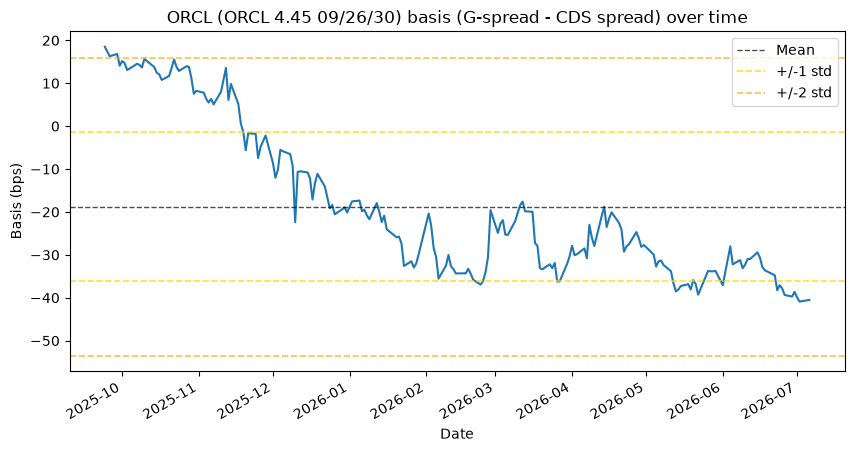

In [80]:
TICKER_TO_PLOT = "ORCL"

plot_data = bond_history[bond_history["ticker"] == TICKER_TO_PLOT].sort_values("date")
security_name = plot_data["SECURITY_NAME"].iloc[0]

mean_basis = plot_data["basis"].mean()
std_basis = plot_data["basis"].std()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(plot_data["date"], plot_data["basis"])
ax.axhline(mean_basis, color="black", linestyle="--", linewidth=1, alpha=0.7, label="Mean")
ax.axhline(mean_basis + std_basis, color="gold", linestyle="--", linewidth=1.2, alpha=0.8, label="+/-1 std")
ax.axhline(mean_basis - std_basis, color="gold", linestyle="--", linewidth=1.2, alpha=0.8)
ax.axhline(mean_basis + 2 * std_basis, color="orange", linestyle="--", linewidth=1.2, alpha=0.7, label="+/-2 std")
ax.axhline(mean_basis - 2 * std_basis, color="orange", linestyle="--", linewidth=1.2, alpha=0.7)
ax.set_title(f"{TICKER_TO_PLOT} ({security_name}) basis (G-spread - CDS spread) over time")
ax.set_xlabel("Date")
ax.set_ylabel("Basis (bps)")
ax.legend()
fig.autofmt_xdate()
plt.show()